** 모델 아키텍처 구성**

(1) 포지셔널 인코딩 추가

In [ ]:
import math
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import QuantileTransformer,MinMaxScaler,StandardScaler
from sklearn.model_selection import cross_val_score,train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable
from torch.utils.data import DataLoader,TensorDataset
from statsmodels.tsa.seasonal import seasonal_decompose
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = 'cpu'

# 1. 하이퍼파라미터 설정
seq_len = 30           # 입력 시퀀스 길이 (예: 30 타임스텝)
batch_size = 64
epochs = 10
learning_rate = 0.001
feature_size = 64      # Transformer 내부 피처 차원
nhead = 4              # 어텐션 헤드 개수
num_layers = 2         # Transformer Encoder 레이어 수

In [ ]:
# 2. 데이터 로딩 및 전처리
# CSV 파일에서 시계열 데이터를 불러옵니다.
# 여기서는 'value'라는 컬럼이 시계열 데이터라고 가정합니다.
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Tomato_Timeseries/green_.csv',index_col=0)
# data = df['time'].values.astype(np.float32)
green_scaler = StandardScaler()
seqence_len=100

Mounted at /content/drive


In [ ]:
class EarlyStopping:
    """주어진 patience 이후로 validation loss가 개선되지 않으면 학습을 조기 중지"""
    def __init__(self, patience=7, verbose=False, delta=0, path='checkpoint.pt'):
        """
        Args:
            patience (int): validation loss가 개선된 후 기다리는 기간
                            Default: 7
            verbose (bool): True일 경우 각 validation loss의 개선 사항 메세지 출력
                            Default: False
            delta (float): 개선되었다고 인정되는 monitered quantity의 최소 변화
                            Default: 0
            path (str): checkpoint저장 경로
                            Default: 'checkpoint.pt'
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):

        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''validation loss가 감소하면 모델을 저장한다.'''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model, self.path)
        self.val_loss_min = val_loss

# 데이터 변환 및 주기설정
def create_sequences(data, seq_length,scaler,dummies=None):
    xs = []
    ys = []
    for i in range(len(data)-seq_length):
        x = data.iloc[i:(i+seq_length)]  # 처음부터 seq_length 까지를 하나의 묶음으로만듦
        if dummies:  # 카테고리화한 더미데이터가 있으면 해당 컬럼은 결과에서 제외
            y = data.iloc[i+seq_length,:-dummies]
        else:
            y = data.iloc[i+seq_length,:]
        xs.append(scaler.transform(x))  # 입력값만 정규화
        ys.append(y)
    return torch.from_numpy(np.array(xs)).float().to(device), torch.from_numpy(np.array(ys)).float().to(device)

In [ ]:
# 데이터 정규화 (다변수 정규화 방식)
green_train, green_test = df.fillna(0).iloc[:int(len(df)*0.6),:],df.iloc[int(len(df)*0.6):,:]  # 6 :4 의 train / test
green_scaler.fit(green_train)
green_x, green_y = create_sequences(green_train, seqence_len, green_scaler, dummies=6)
train_x, val_x, train_y, val_y = train_test_split(
    green_x, green_y, random_state=219, test_size=0.2, shuffle=True
)

In [ ]:
print(df.columns)

Index(['X3WAY1VOL', 'X3WAY2VOL', 'XABHUM', 'XCO2', 'XCO2SET', 'XCUR1VOL',
       'XCUR2VOL', 'XCUR3VOL', 'XCUR4VOL', 'XDHUM', 'XDUALVOL1', 'XDUALVOL2',
       'XEC1', 'XEC2', 'XGNDHUM', 'XGNDTEMP', 'XHEATCONT', 'XHEATRST',
       'XHEATTEMP', 'XHUMLACK', 'XINHUM', 'XINHUM1', 'XINHUM2', 'XINHUM3',
       'XINTEMP', 'XINTEMP1', 'XINTEMP2', 'XINTEMP3', 'XOUTTEMP', 'XPH2',
       'XRAIN', 'XSIDEVOL1', 'XSIDEVOL2', 'XSKYVOL1', 'XSKYVOL2', 'XSTHUM',
       'XSUNADD', 'XSUNVOL', 'XVENT2RST', 'XVENTCONT', 'XVENTCONT2',
       'XVENTRST', 'XVENTTEMP', 'XVENTTEMP2', 'XWATERTEMP', 'XWATERTEMP2',
       'XWINDSP', 'farmId_gjkss', 'farmId_jsbbj', 'farmId_kjbmr',
       'farmId_kjrjc', 'farmId_scjsg', 'farmId_scjyh', 'farmId_hajml'],
      dtype='object')


In [ ]:
# 데이터 정규화 (평균 0, 분산 1)
# mean = data.mean()
# std = data.std()
# data = (data - mean) / std

In [ ]:
# 슬라이딩 윈도우 방식으로 입력 시퀀스와 타깃 생성
# def create_sequences(data, seq_len):
#     xs, ys = [], []
#     for i in range(len(data) - seq_len):
#         x = data[i:i + seq_len]
#         y = data[i + seq_len]
#         xs.append(x)
#         ys.append(y)
#     return np.array(xs), np.array(ys)

# X, y = create_sequences(data, seq_len)

In [ ]:
# 3. Dataset 및 DataLoader 정의
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X  # 이미 torch.Tensor이고 GPU에 있음
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = TimeSeriesDataset(train_x, train_y)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TimeSeriesDataset(val_x, val_y)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
# 4. Positional Encoding 클래스 정의
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)  # [max_len, 1, d_model]
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: [seq_len, batch_size, d_model]
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)

In [ ]:
# 5. Transformer 기반 시계열 예측 모델 정의
class TransformerTimeSeries(nn.Module):
    def __init__(self, input_dim, feature_size=64, num_layers=2, nhead=4, dropout=0.1, output_dim=1):
        super(TransformerTimeSeries, self).__init__()
        # 입력 차원(1)을 내부 피처 차원(feature_size)로 변환
        self.input_linear = nn.Linear(input_dim, feature_size)
        self.pos_encoder = PositionalEncoding(feature_size, dropout)
        encoder_layers = nn.TransformerEncoderLayer(d_model=feature_size, nhead=nhead, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
        # 마지막 타임스텝의 출력으로부터 최종 예측 (회귀 문제를 위한 단일 값)
        self.decoder = nn.Linear(feature_size, output_dim)
        self.feature_size = feature_size

    def forward(self, src):
        # src shape: [batch_size, seq_len, 1]
        src = self.input_linear(src)            # → [batch_size, seq_len, feature_size]
        src = src.transpose(0, 1)                # Transformer는 [seq_len, batch_size, feature_size] 형식을 사용
        src = self.pos_encoder(src)
        output = self.transformer_encoder(src)
        # 마지막 타임스텝의 출력을 사용해 예측값 도출
        output = self.decoder(output[-1, :, :])
        return output

In [ ]:
# 6. 모델 초기화, 손실 함수, 옵티마이저 설정
model = TransformerTimeSeries(
    input_dim=train_x.shape[2],           # 예: 54
    output_dim=train_y.shape[1],          # 예: 1, 또는 다변수라면 3 등
    feature_size=64,
    num_layers=2,
    nhead=4,
    dropout=0.1
).to(device)

# model = TransformerTimeSeries(feature_size=feature_size, num_layers=num_layers, nhead=nhead, dropout=0.1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

early_stopping = EarlyStopping(
    patience=10,             # 검증 성능 개선 없을 시 대기할 epoch 수
    verbose=True,            # 개선될 때마다 메시지 출력
    path="/content/drive/MyDrive/Colab Notebooks/Tomato_Timeseries/transformer_best.pt"  # 모델 저장 경로
)


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [ ]:
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_x.size(0)

    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for val_x, val_y in val_loader:
            val_output = model(val_x)
            loss = criterion(val_output, val_y)
            val_loss += loss.item() * val_x.size(0)
    val_loss /= len(val_loader.dataset)

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Early stopping triggered")
        break


Epoch 1/10, Train Loss: 23831.4448, Val Loss: 19790.3945
Validation loss decreased (inf --> 19790.394531).  Saving model ...
Epoch 2/10, Train Loss: 17088.6886, Val Loss: 12857.5938
Validation loss decreased (19790.394531 --> 12857.593750).  Saving model ...
Epoch 3/10, Train Loss: 10900.0678, Val Loss: 8311.5693
Validation loss decreased (12857.593750 --> 8311.569336).  Saving model ...
Epoch 4/10, Train Loss: 7241.9926, Val Loss: 6024.4702
Validation loss decreased (8311.569336 --> 6024.470215).  Saving model ...
Epoch 5/10, Train Loss: 5219.8210, Val Loss: 4584.3257
Validation loss decreased (6024.470215 --> 4584.325684).  Saving model ...
Epoch 6/10, Train Loss: 3815.2734, Val Loss: 3354.6267
Validation loss decreased (4584.325684 --> 3354.626709).  Saving model ...
Epoch 7/10, Train Loss: 2715.0769, Val Loss: 2380.4846
Validation loss decreased (3354.626709 --> 2380.484619).  Saving model ...
Epoch 8/10, Train Loss: 1866.0841, Val Loss: 1664.3535
Validation loss decreased (2380.48

In [ ]:
# green_train은 DataFrame
# dummies가 예측에 포함되지 않는 변수 개수라고 했으니, 타깃은 그 앞쪽까지만
dummies = 6  # 예측에 사용하지 않은 컬럼 수
green_y_scaler = StandardScaler()
green_y_scaler.fit(green_train.iloc[:, :-dummies])  # 예측 대상만

StandardScaler()

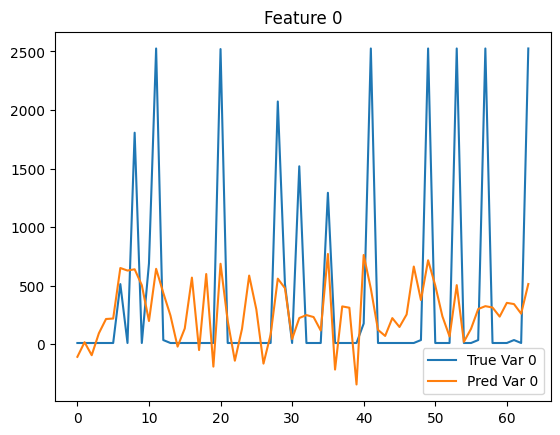

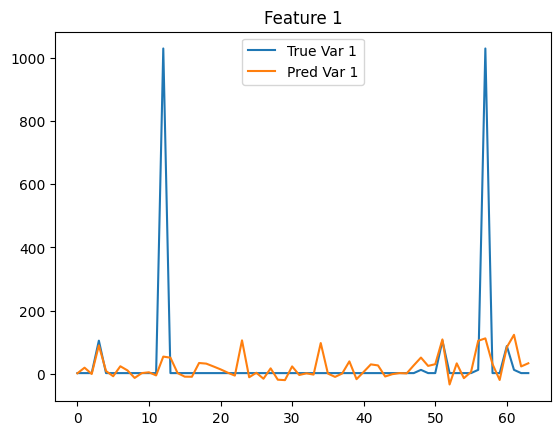

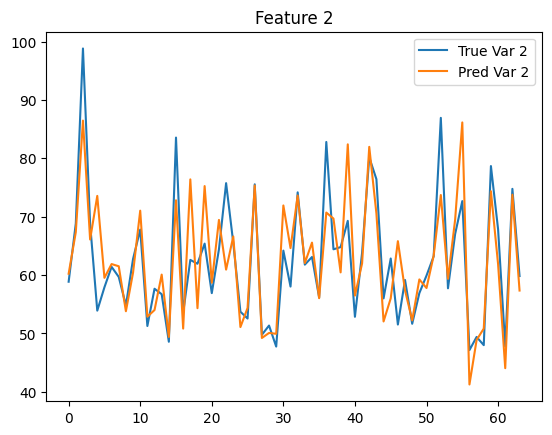

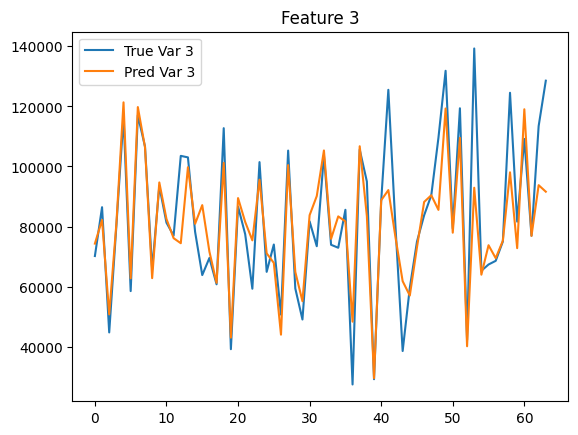

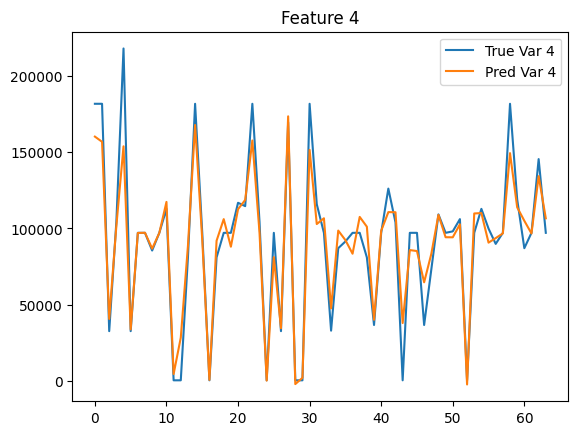

In [ ]:
model.eval()
with torch.no_grad():
    sample_x, sample_y = next(iter(train_loader))
    predictions = model(sample_x)

    # → shape: [batch, target_dim]
    pred_np = predictions.cpu().numpy()
    true_np = sample_y.cpu().numpy()

    # 🔥 y 스케일러로 역변환
    pred_denorm = green_y_scaler.inverse_transform(pred_np)
    true_denorm = green_y_scaler.inverse_transform(true_np)

    # 결과 출력
    # print("예측값 (상위 5개):", pred_denorm[:5])
    # print("실제값 (상위 5개):", true_denorm[:5])

import matplotlib.pyplot as plt

for i in range(5):  # 상위 5개 피처만 예시로
    plt.plot(true_denorm[:, i], label=f"True Var {i}")
    plt.plot(pred_denorm[:, i], label=f"Pred Var {i}")
    plt.legend()
    plt.title(f"Feature {i}")
    plt.show()